In [2]:
import pandas as pd
import numpy as np

In [3]:
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

In [4]:
#Basic Exploration
print(matches.shape)
print(deliveries.shape)

print(matches.columns.tolist())
print(deliveries.columns.tolist())

print(matches.head())
print(deliveries.head())


print(matches.isnull().sum())
print(deliveries.isnull().sum())

(1095, 20)
(260920, 17)
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        te

In [5]:
matches.describe()
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


In [6]:
#Total Matches won by Each Team (2008-2024)
matches['winner'].value_counts()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [7]:
#Merging Old team name with the new one

matches['winner'] = matches['winner'].replace({ 'Kings XI Punjab':'Punjab Kings',
    'Delhi Daredevils':'Delhi Capitals',
    'Deccan Chargers':'Sunrisers Hyderabad',
    'Rising Pune Supergiant':'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'})

matches['winner'].value_counts()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Sunrisers Hyderabad            117
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [ ]:
#Cleaning and Making names of venues consistent

matches['venue'] = matches['venue'].str.split(',').str[0]
matches['venue'] = matches['venue'].replace({'M.Chinnaswamy Stadium':'M Chinnaswamy Stadium',
    'Punjab Cricket Association Stadium':'Maharaja Yadavindra Singh International Cricket Stadium',
    'Feroz Shah Kotla':'Arun Jaitley Stadium',
    'Sardar Patel Stadium':'Narendra Modi Stadium',
    'Zayed Cricket Stadium':'Sheikh Zayed Stadium'
    })
matches['venue'].unique()

array(['M Chinnaswamy Stadium',
       'Maharaja Yadavindra Singh International Cricket Stadium',
       'Arun Jaitley Stadium', 'Wankhede Stadium', 'Eden Gardens',
       'Sawai Mansingh Stadium', 'Rajiv Gandhi International Stadium',
       'MA Chidambaram Stadium', 'Dr DY Patil Sports Academy', 'Newlands',
       "St George's Park", 'Kingsmead', 'SuperSport Park', 'Buffalo Park',
       'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium', 'Narendra Modi Stadium',
       'Barabati Stadium', 'Vidarbha Cricket Association Stadium',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Holkar Cricket Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Subrata Roy Sahara Stadium',
       'Maharashtra Cricket Association Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'JSCA International Stadium Complex', 'Sheikh Zayed Stadium',
       'Sharjah Cricket Stadium', 'D

In [ ]:
#Checking how many times toss winner team won the matches and percentage of matches won by teams who won the toss
toss_winners = matches[matches['toss_winner'] == matches['winner']]
toss_winners.shape
toss_win_count = toss_winners.shape[0]

#Omitting the matches with no Result

matches_clean = matches[matches['winner'].notna()]
matches_count = matches_clean.shape[0]

#Finding percentages of the match won by the teams who won the Toss

win_percentage = ((toss_win_count/matches_count)*100)
print(f"{win_percentage:.2f}%")

36.88%


In [ ]:
#Finding Top 10 run scorer 
batter_runs = deliveries.groupby('batter')['batsman_runs'].sum()
batter_runs = batter_runs.sort_values(ascending=False)
top_10_batters = batter_runs.head(10).reset_index()
top_10_batters

,batter,batsman_runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


In [ ]:
#Finding Batting Averages
matches_played_all = deliveries.groupby('batter')['match_id'].nunique().rename('matches_played')
batter_averages = top_10_batters.merge(matches_played_all,on = 'batter')
batter_averages = batter_averages[['batter','matches_played']]
batter_averages = batter_averages.merge(batter_runs,on = 'batter')
batter_averages['average'] = batter_averages['batsman_runs']/batter_averages['matches_played']

#sorting Batter on the basis of averages
batter_averages = batter_averages.sort_values('average',ascending=False)
batter_averages



,batter,matches_played,batsman_runs,average
3,DA Warner,184,6567,35.690217
7,CH Gayle,141,4997,35.439716
0,V Kohli,244,8014,32.844262
1,S Dhawan,221,6769,30.628959
6,AB de Villiers,170,5181,30.476471
4,SK Raina,200,5536,27.680000
2,RG Sharma,251,6630,26.414343
8,RV Uthappa,197,4954,25.147208
5,MS Dhoni,228,5243,22.995614
9,KD Karthik,233,4843,20.785408


In [ ]:
#Starting Visualization
import matplotlib.pyplot as plt
import seaborn as sns

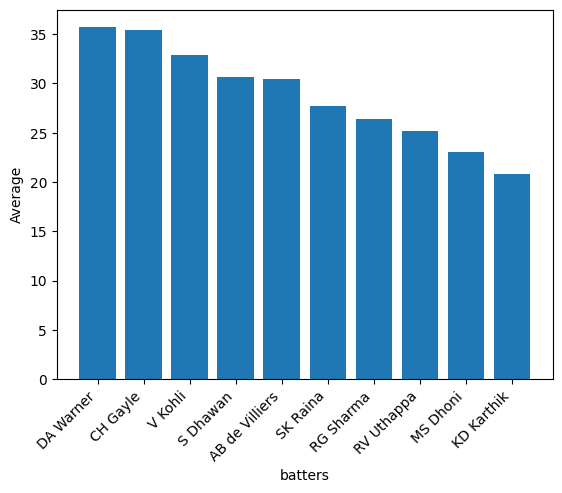

In [ ]:
#Visualizing top Batters with respect to average using Bar Chart
plt.bar(batter_averages['batter'],batter_averages['average'])
plt.xlabel('batters')
plt.ylabel('Average')
plt.xticks(rotation=45,ha='right')
plt.show()

In [ ]:
#Finding top 10 Bowlers
bowler_wickets = deliveries.groupby('bowler')['is_wicket'].sum()
bowler_wickets = bowler_wickets.sort_values(ascending=False)
top_10_bowlers = bowler_wickets.head(10).reset_index()
top_10_bowlers

,bowler,is_wicket
0,YS Chahal,213
1,DJ Bravo,207
2,PP Chawla,201
3,SP Narine,200
4,R Ashwin,198
5,B Kumar,195
6,SL Malinga,188
7,A Mishra,183
8,JJ Bumrah,182
9,RA Jadeja,169


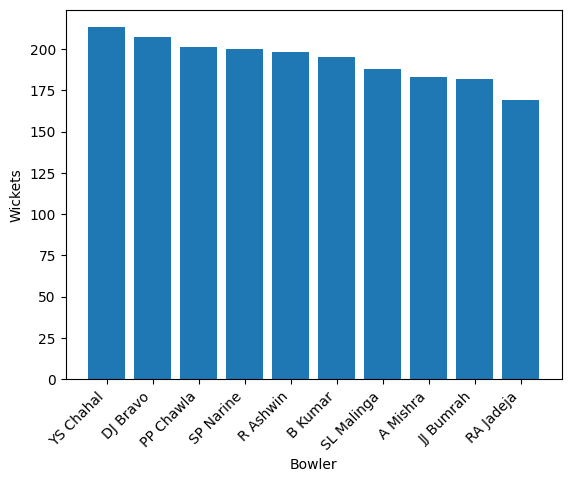

In [ ]:
#Creating a bar chart of Top Bowlers
plt.bar(top_10_bowlers['bowler'],top_10_bowlers['is_wicket'])
plt.xlabel('Bowler')
plt.ylabel('Wickets')
plt.xticks(rotation = 45,ha ='right')
plt.show()

In [ ]:
#Total Matches Hosted by Each Venue (2008-2024)
